# $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ Majorana Hamiltonians - check states

Created: 03-08-2026

Objectives:
* Check the states that were saved [here](../../save_states/z2_f_x_z2_t_majorana_hamiltonians.ipynb).

# Imports

In [2]:
from time import time

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
from tqdm import tqdm

In [6]:
from functools import reduce
from itertools import product, combinations_with_replacement

In [7]:
import quimb.tensor as qtn
import quimb as qu

In [8]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [9]:
from humanize import naturalsize

In [10]:
TOP_DATA_DIR = r"../../data/"
TRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_majorana_triv_to_nontriv_n1_10_site_ed"
NONTRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_majorana_nontriv_n1_to_nontriv_cocyle_10_site_ed"

# Import states

In [11]:
triv_cocycle_data = [
    np.load(rf'{TRIV_COCYCLE_DIR}/{i}.npz')
    for i in range(0, 101, 5)
]

In [12]:
nontriv_cocycle_data = [
    np.load(rf'{NONTRIV_COCYCLE_DIR}/{i}.npz')
    for i in range(0, 101, 5)
]

In [13]:
len(triv_cocycle_data), len(nontriv_cocycle_data)

(21, 21)

In [14]:
triv_groundstates = [
    x['psi'] for x in triv_cocycle_data
]

nontriv_groundstates = [
    x['psi'] for x in nontriv_cocycle_data
]

In [15]:
len(triv_groundstates), len(nontriv_groundstates)

(21, 21)

# Definitions

In [16]:
L = 10

In [17]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

In [18]:
print(basis)

reference states: 
array index   /   Fock state   /   integer repr. 
	      0.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 1 1>  1023 
	      1.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 1 0>  1022 
	      2.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 0 1>  1021 
	      3.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 1 0 0>  1020 
	      4.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 1 1>  1019 
	      5.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 1 0>  1018 
	      6.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 0 1>  1017 
	      7.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 1 0 0 0>  1016 
	      8.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 1 1>  1015 
	      9.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 1 0>  1014 
	     10.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 0 1>  1013 
	     11.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 1 0 0>  1012 
	     12.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1 1 1 0 0 1 1>  1011 
	     13.  |1 1 1 1 1 1 1 1 1 1>  1023 |1 1 1 1

# Analysis

## Energies

In [19]:
triv_energies = [x['energy'] for x in triv_cocycle_data]

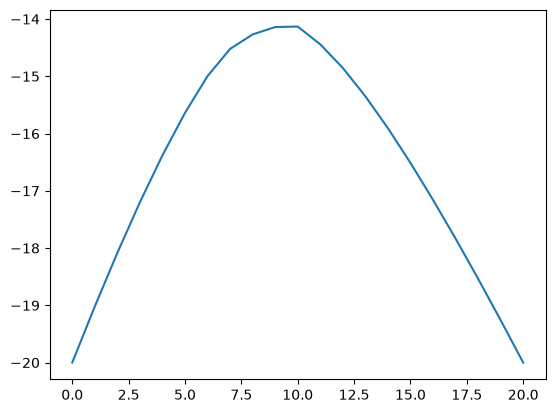

In [20]:
plt.plot(triv_energies)

In [21]:
nontriv_energies = [x['energy'] for x in nontriv_cocycle_data]

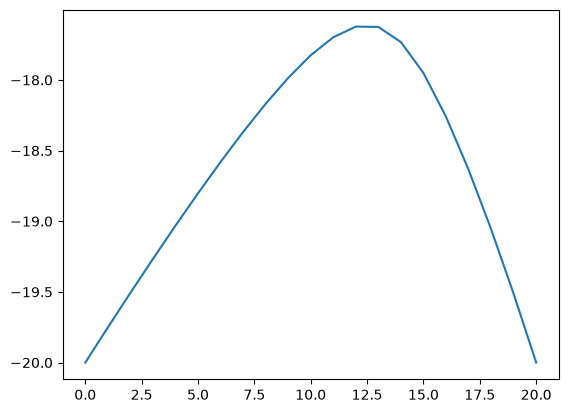

In [22]:
plt.plot(nontriv_energies)

## Check $T=XK$ symmetry

In [23]:
x_sym = quantum_operator(
    {"x": [["x"*L + "|", [[1, *list(range(L))]]]]},
    basis=basis,
    dtype=np.complex128
)

Hermiticity check passed!


/tmp/ipykernel_41048/1830159187.py:1: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  x_sym = quantum_operator(
/tmp/ipykernel_41048/1830159187.py:1: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  x_sym = quantum_operator(


In [24]:
psi = triv_cocycle_data[0]['psi']

In [25]:
psi.shape

(1048576, 1)

In [26]:
naturalsize(psi.nbytes)

'16.8 MB'

In [27]:
sym_psi = psi.conj()

In [28]:
np.sum(sym_psi.conj()*sym_psi)

np.complex128(1.0000000000000007-2.4062488388925284e-17j)

In [29]:
np.sum(psi.conj()*psi)

np.complex128(1.0000000000000007+2.4062488388925284e-17j)

In [30]:
np.abs(np.sum(sym_psi.conj()*psi))

np.float64(1.0000000000000007)

## Expectation values

In [31]:
one_site_paulis = [
    quantum_operator(
        {s: [[f"{s}|" , [[1, 0]]]]},
        basis=basis,
        dtype=np.complex128
    )
    for s in "xyz"
]

Hermiticity check passed!


/tmp/ipykernel_41048/4294405670.py:2: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  quantum_operator(
/tmp/ipykernel_41048/4294405670.py:2: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  quantum_operator(


Hermiticity check passed!
Hermiticity check passed!


In [32]:
one_site_fermion_occupation = quantum_operator(
    {"n": [["|n" , [[1, 0]]]]},
    basis=basis,
    dtype=np.complex128
)

Hermiticity check passed!


/tmp/ipykernel_41048/2974233378.py:1: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  one_site_fermion_occupation = quantum_operator(
/tmp/ipykernel_41048/2974233378.py:1: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  one_site_fermion_occupation = quantum_operator(


In [33]:
triv_groundstates = [
    x['psi'] for x in triv_cocycle_data
]

nontriv_groundstates = [
    x['psi'] for x in nontriv_cocycle_data
]

In [34]:
triv_pauli_expectations = np.array([
    [op.expt_value(psi) for psi in triv_groundstates]
    for op in one_site_paulis
])

nontriv_pauli_expectations = np.array([
    [op.expt_value(psi) for psi in nontriv_groundstates]
    for op in one_site_paulis
])

In [35]:
np.round(triv_pauli_expectations, 3)

array([[[ 0.   -0.j],
        [-0.   -0.j],
        [ 0.   -0.j],
        [-0.   -0.j],
        [ 0.   +0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [-0.   +0.j],
        [-0.   -0.j],
        [-0.   +0.j],
        [ 0.   +0.j],
        [-0.   -0.j],
        [-0.   +0.j],
        [-0.   -0.j],
        [-0.   +0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [-0.   -0.j]],

       [[ 0.   +0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [ 0.   +0.j],
        [-0.   +0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [-0.   +0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [-0.   -0.j],
        [ 0.   +0.j],
        [ 0.   -0.j],
        [ 0.   -0.j],
        [-0.   -0.j],
        [ 0.   -0.j],
        [ 0.   +0.j],
        [ 0.   +0.j]],

       [[ 1.   +0.j],
        [ 0.999+0.j],
        [ 0.997+0.j],
      

In [36]:
parameters = np.linspace(0, 1, 21)

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


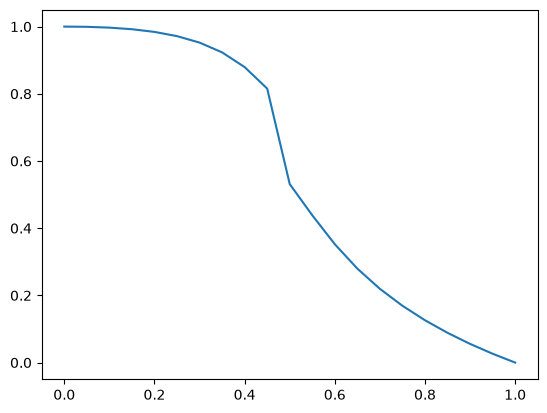

In [37]:
plt.plot(parameters, triv_pauli_expectations[2])

In [38]:
np.round(nontriv_pauli_expectations, 3)

array([[[-0.+0.j],
        [ 0.-0.j],
        [ 0.+0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [-0.-0.j],
        [-0.-0.j],
        [ 0.+0.j],
        [ 0.-0.j],
        [ 0.+0.j],
        [-0.-0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [ 0.-0.j],
        [-0.-0.j],
        [ 0.-0.j],
        [ 0.+0.j]],

       [[-0.+0.j],
        [-0.+0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [ 0.+0.j],
        [ 0.-0.j],
        [ 0.+0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [-0.-0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [ 0.-0.j],
        [ 0.-0.j]],

       [[-0.+0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [-0.+0.j],
        [-0.+0.j],
        

All vanishing expectations is odd...

In [39]:
triv_fermion_occupations = np.array([
    one_site_fermion_occupation.expt_value(psi) for psi in triv_groundstates
])

nontriv_fermion_occupations = np.array([
    one_site_fermion_occupation.expt_value(psi) for psi in nontriv_groundstates
])

In [40]:
triv_fermion_occupations

array([[4.71870865e-30+0.j],
       [1.38793241e-03+0.j],
       [6.23118039e-03+0.j],
       [1.59525546e-02+0.j],
       [3.28222703e-02+0.j],
       [6.02658156e-02+0.j],
       [1.01146037e-01+0.j],
       [2.51466540e-01+0.j],
       [2.99952817e-01+0.j],
       [3.39705324e-01+0.j],
       [3.70515216e-01+0.j],
       [3.95413403e-01+0.j],
       [4.15453606e-01+0.j],
       [4.32064561e-01+0.j],
       [4.46115571e-01+0.j],
       [4.58187119e-01+0.j],
       [4.68688604e-01+0.j],
       [4.77919646e-01+0.j],
       [4.86105747e-01+0.j],
       [4.93420483e-01+0.j],
       [5.00000000e-01+0.j]])

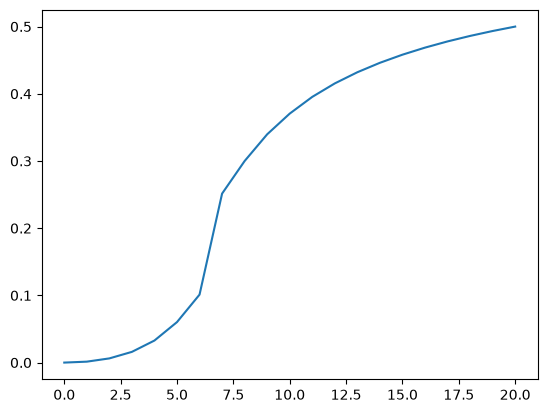

In [41]:
plt.plot(triv_fermion_occupations)

In [42]:
nontriv_fermion_occupations

array([[0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j],
       [0.5+0.j]])

In [43]:
two_site_paulis = [
    quantum_operator(
        {s: [[f"{s+s}|" , [[1, 0, 1]]]]},
        basis=basis,
        dtype=np.complex128
    )
    for s in "xyz"
]

Hermiticity check passed!


/tmp/ipykernel_41048/3625545787.py:2: UserWarning: Test for symmetries not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_symm=False in hamiltonian
  quantum_operator(
/tmp/ipykernel_41048/3625545787.py:2: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  quantum_operator(


Hermiticity check passed!
Hermiticity check passed!


In [44]:
triv_two_site_pauli_expectations = np.array([
    [op.expt_value(psi) for psi in triv_groundstates]
    for op in two_site_paulis
])

nontriv_two_site_pauli_expectations = np.array([
    [op.expt_value(psi) for psi in nontriv_groundstates]
    for op in two_site_paulis
])

In [45]:
np.round(triv_two_site_pauli_expectations, 3)

array([[[-0.   -0.j],
        [-0.026+0.j],
        [-0.055+0.j],
        [-0.084+0.j],
        [-0.114-0.j],
        [-0.14 -0.j],
        [-0.159+0.j],
        [-0.118-0.j],
        [-0.109-0.j],
        [-0.094-0.j],
        [-0.025+0.j],
        [-0.017+0.j],
        [-0.01 -0.j],
        [-0.005-0.j],
        [-0.003-0.j],
        [-0.001-0.j],
        [-0.   -0.j],
        [-0.   +0.j],
        [-0.   -0.j],
        [-0.   +0.j],
        [-0.   -0.j]],

       [[ 0.   +0.j],
        [ 0.026-0.j],
        [ 0.055-0.j],
        [ 0.086-0.j],
        [ 0.118+0.j],
        [ 0.149+0.j],
        [ 0.175-0.j],
        [ 0.139+0.j],
        [ 0.141+0.j],
        [ 0.141+0.j],
        [ 0.189-0.j],
        [ 0.171+0.j],
        [ 0.149+0.j],
        [ 0.125+0.j],
        [ 0.103-0.j],
        [ 0.081-0.j],
        [ 0.062+0.j],
        [ 0.044+0.j],
        [ 0.028-0.j],
        [ 0.013-0.j],
        [-0.   +0.j]],

       [[ 1.   +0.j],
        [ 0.999+0.j],
        [ 0.997+0.j],
      

In [46]:
np.round(nontriv_two_site_pauli_expectations, 3)

array([[[ 0.+0.j],
        [-0.-0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [ 0.+0.j],
        [ 0.+0.j],
        [ 0.-0.j],
        [ 0.+0.j],
        [ 0.-0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [ 0.-0.j],
        [ 0.+0.j],
        [ 0.+0.j],
        [ 0.-0.j],
        [-0.+0.j],
        [-0.-0.j],
        [-0.-0.j],
        [ 0.-0.j],
        [-0.-0.j],
        [-0.-0.j]],

       [[-0.+0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [-0.-0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [ 0.+0.j],
        [-0.-0.j],
        [-0.-0.j],
        [-0.-0.j],
        [-0.+0.j],
        [-0.-0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [ 0.-0.j],
        [ 0.-0.j]],

       [[ 0.+0.j],
        [-0.+0.j],
        [-0.+0.j],
        [-0.+0.j],
        [-0.+0.j],
        [ 0.+0.j],
        [ 0.+0.j],
        [ 0.+0.j],
        [ 0.+0.j],
        [-0.+0.j],
        

Are the nontrivial states just wrong?

In [47]:
overlaps = np.zeros((21, 21))

In [48]:
overlaps.shape

(21, 21)

In [49]:
for i, j in tqdm(combinations_with_replacement(range(21), 2)):
    overlap = np.abs(np.sum(nontriv_groundstates[i].conj() * nontriv_groundstates[j]))
    overlaps[i,j] = overlap
    overlaps[j,i] = overlap

231it [00:01, 165.63it/s]


In [50]:
np.round(overlaps, 3)

array([[1.   , 1.   , 0.999, 0.998, 0.995, 0.991, 0.985, 0.977, 0.964,
        0.944, 0.913, 0.861, 0.777, 0.645, 0.48 , 0.328, 0.22 , 0.152,
        0.109, 0.081, 0.063],
       [1.   , 1.   , 1.   , 0.999, 0.997, 0.994, 0.989, 0.981, 0.969,
        0.95 , 0.92 , 0.871, 0.787, 0.657, 0.491, 0.338, 0.229, 0.159,
        0.115, 0.086, 0.067],
       [0.999, 1.   , 1.   , 1.   , 0.998, 0.996, 0.992, 0.985, 0.974,
        0.957, 0.929, 0.881, 0.799, 0.67 , 0.504, 0.349, 0.238, 0.167,
        0.122, 0.092, 0.072],
       [0.998, 0.999, 1.   , 1.   , 1.   , 0.998, 0.995, 0.989, 0.98 ,
        0.964, 0.937, 0.891, 0.812, 0.684, 0.518, 0.363, 0.25 , 0.177,
        0.13 , 0.099, 0.078],
       [0.995, 0.997, 0.998, 1.   , 1.   , 0.999, 0.997, 0.993, 0.985,
        0.971, 0.947, 0.903, 0.826, 0.7  , 0.535, 0.378, 0.263, 0.188,
        0.14 , 0.108, 0.085],
       [0.991, 0.994, 0.996, 0.998, 0.999, 1.   , 0.999, 0.996, 0.99 ,
        0.978, 0.956, 0.916, 0.842, 0.719, 0.555, 0.397, 0.279, 0.202

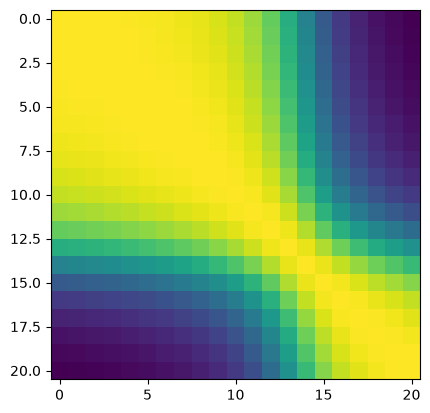

In [51]:
plt.imshow(overlaps)

In [58]:
for i, j in tqdm(combinations_with_replacement(range(21), 2)):
    overlap = np.abs(np.sum(triv_groundstates[i].conj() * triv_groundstates[j]))
    overlaps[i,j] = overlap
    overlaps[j,i] = overlap

231it [00:01, 161.77it/s]


In [59]:
np.round(overlaps, 3)

array([[1.   , 0.996, 0.981, 0.951, 0.901, 0.823, 0.712, 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.996, 1.   , 0.995, 0.975, 0.936, 0.868, 0.763, 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.981, 0.995, 1.   , 0.993, 0.967, 0.912, 0.818, 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.951, 0.975, 0.993, 1.   , 0.99 , 0.953, 0.876, 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.901, 0.936, 0.967, 0.99 , 1.   , 0.986, 0.932, 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   , 0.   , 0.   ],
       [0.823, 0.868, 0.912, 0.953, 0.986, 1.   , 0.98 , 0.   , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   

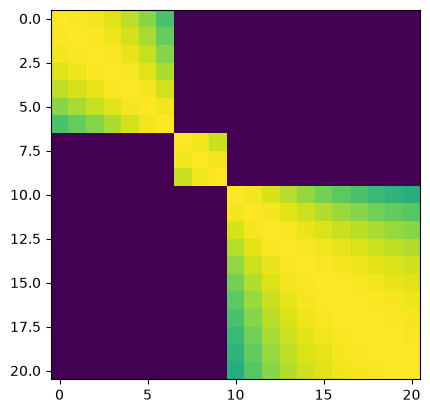

In [60]:
plt.imshow(overlaps)

Fascinating! Clear sign of a phase transition, I haven't seen this before. So something is changing!

## Check entanglement via $\rho$

In [52]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(2, 16)),
    'left_defect_sites': [2, 3],
    'right_defect_sites': [14, 15],
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [53]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [54]:
def get_left_right_schmidt_values(quspin_psi, domains_dict):
    inds = (
        [f'k{2*i}' for i in range(domains_dict['num_system_sites']//2)]
        + [f'k{2*i+1}' for i in range(domains_dict['num_system_sites']//2)]
    )

    qt_psi = qtn.Tensor(
        quspin_psi[::-1].reshape((2,)*domains_dict['num_system_sites']),
        inds=inds
    )

    rho = get_rdm_from_quimb_psi(qt_psi, domains_dict['symmetry_sites'])

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )
    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    rho_lr = (
        rho
        .reindex({f'k{i}': f'b{i}' for i in central_sites})
        .contract()
    )

    left_defect_inds = (
        [f'k{i}' for i in domains_dict['left_defect_sites']]
        + [f'b{i}' for i in domains_dict['left_defect_sites']]
    )

    split_rho_lr = qtn.tensor_core.tensor_split(
        rho_lr,
        left_inds=left_defect_inds,
        absorb=None,
        bond_ind='vH'
    )

    out = split_rho_lr.tensors[1].data

    return out

In [55]:
triv_schmidt_vals = [
    get_left_right_schmidt_values(psi, domains_dict)
    for psi in triv_groundstates
]

nontriv_schmidt_vals = [
    get_left_right_schmidt_values(psi, domains_dict)
    for psi in nontriv_groundstates
]

In [56]:
triv_schmidt_vals

[array([1.]),
 array([9.96537267e-01, 1.66575247e-05, 2.36647064e-06, 1.04914670e-06,
        1.49421911e-07]),
 array([9.84564744e-01, 3.22056252e-04, 4.48751515e-05, 2.08371904e-05,
        2.93651335e-06, 1.15382345e-08, 6.73379780e-09, 1.03917029e-09,
        7.30274749e-10, 1.12697149e-10]),
 array([9.61048126e-01, 1.93837972e-03, 2.59791012e-04, 1.32385296e-04,
        1.82721575e-05, 2.59199357e-07, 2.27487940e-07, 4.45248482e-08,
        1.47109213e-08, 2.87928027e-09, 2.52701838e-09]),
 array([9.21816641e-01, 7.05413357e-03, 8.83847813e-04, 5.29556370e-04,
        7.05728293e-05, 3.83012838e-06, 1.53941359e-06, 7.69505586e-07,
        1.03952336e-07, 5.19625809e-08, 2.08849144e-08, 3.93513160e-09,
        5.24426456e-10, 3.14209490e-10]),
 array([8.61867410e-01, 1.86076429e-02, 2.08871011e-03, 1.63691181e-03,
        2.06418352e-04, 6.52565277e-05, 3.22709720e-05, 7.94137069e-06,
        4.81673589e-06, 1.18532176e-06, 5.86171017e-07, 8.96114366e-08,
        1.13002087e-08, 8.

In [57]:
nontriv_schmidt_vals

[array([0.25]),
 array([2.50000000e-01, 6.63437798e-05, 6.63437798e-05]),
 array([0.25      , 0.00030267, 0.00030267]),
 array([0.25      , 0.00078305, 0.00078305]),
 array([0.25      , 0.00161531, 0.00161531]),
 array([0.25      , 0.00295876, 0.00295876]),
 array([0.25      , 0.00505241, 0.00505241]),
 array([0.25      , 0.00826005, 0.00826005]),
 array([0.25      , 0.01313959, 0.01313959]),
 array([0.25      , 0.02053464, 0.02053464]),
 array([0.25      , 0.03162023, 0.03162023]),
 array([0.25      , 0.04753252, 0.04753252]),
 array([0.25      , 0.06727936, 0.06727936]),
 array([0.25      , 0.08247285, 0.08247285]),
 array([0.25      , 0.07837795, 0.07837795]),
 array([0.25      , 0.05577362, 0.05577362]),
 array([0.25      , 0.03162023, 0.03162023]),
 array([0.25      , 0.01488419, 0.01488419]),
 array([0.25      , 0.00546208, 0.00546208]),
 array([0.25      , 0.00112886, 0.00112886]),
 array([0.25])]

Pretty much as expected...

# Conclusion
More or less ok, but weird things happening with expectations, especially in non-trivial states.